In [151]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [152]:
Path.cwd()

PosixPath('/Users/cube/source/dhbw/exploration/src2')

In [153]:
root_dir = Path.cwd().parent
temp_dir = root_dir / ".temp"
assert temp_dir.exists()

temp_dir

PosixPath('/Users/cube/source/dhbw/exploration/.temp')

In [154]:
dataset_path = temp_dir / "vehicles.csv"
dataset_path

PosixPath('/Users/cube/source/dhbw/exploration/.temp/vehicles.csv')

In [155]:
images_path = Path.cwd() / ".." / "charged-ieee" / "images"
images_path

PosixPath('/Users/cube/source/dhbw/exploration/src2/../charged-ieee/images')

Globals

In [156]:
RNG = 99

# Load

In [157]:
df = pd.read_csv(dataset_path)
df_og = df.copy()
df_og

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


# General

In [158]:
len(df)

426880

In [159]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [160]:
print("Mean Price:", df["price"].mean())
print("Median Price:", df["price"].median())

Mean Price: 75199.0331873126
Median Price: 13950.0


In [131]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='str')

In [132]:
cols = df.columns.tolist()
cols_drop = [
    "id",
    "url",
    "region_url",
    "image_url",
    "description",
    "county",  # (all missing)
    "VIN",
    "lat",
    "long",
    "posting_date",
    "model",  # (not determined, too many)
    "size",  # (72% missing)
]

col_label = "price"  # (complete -> required)
cols_features_num = [
    "year",  # (1% missing -> drop)
    "odometer",  # (1% missing -> drop)
]
cols_features_cat = [
    "region",  # target encode (complete -> required)
    "state",  # target encode (complete -> required)
    #
    "manufacturer",  # target encode (4% missing -> mark)
    #
    "condition",  # onehot encode (41% missing)
    "cylinders",  # onehot encode (42% missing)
    "fuel",  # onehot encode (1% missing)
    "title_status",  # onehot encode (2% missing)
    "transmission",  # onehot encode (1% missing)
    "drive",  # onehot encode (31% missing)
    "type",  # onehot encode (22% missing)
    "paint_color",  # onehot encode (31% missing)
]

assert set(cols) == (
    set(cols_drop) | set(cols_features_num) | set(cols_features_cat) | {col_label}
)

# Plots

#### Settings

In [133]:
fm.fontManager.addfont(Path.cwd() / ".." / "resources" / "LibertinusSerif-Regular.ttf")

plt.rc("font", size=9)
plt.rcParams["figure.dpi"] = 500
# plt.style.use("dark_background")
plt.rcParams["font.family"] = "Libertinus Serif"

### Plots

In [134]:
df = df_og.copy()

Price distribution

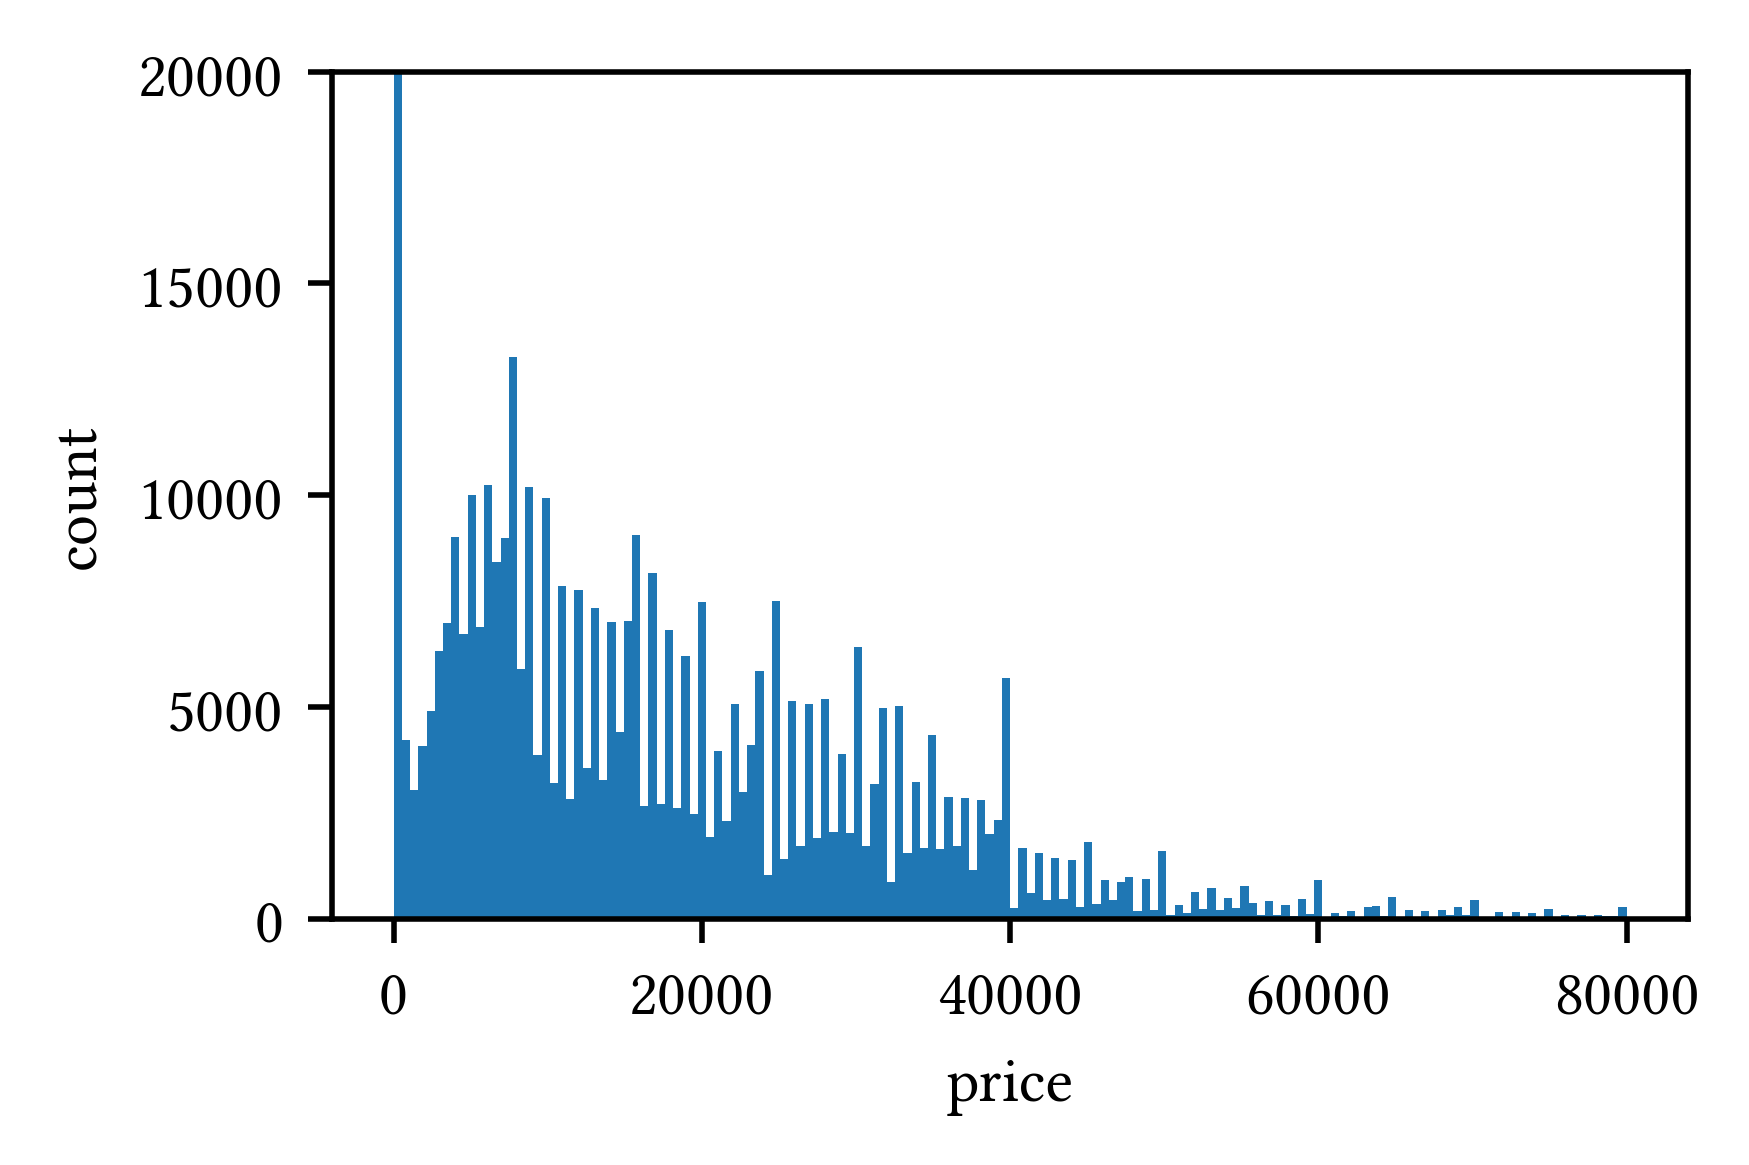

In [135]:
plt.figure(figsize=(3.5, 2.2))
plt.hist(df[df["price"] < 80000]["price"], bins=150)
plt.ylim(0, 20000)
plt.xlabel("price")
plt.ylabel("count")

plt.savefig(images_path / "price_distribution.png", bbox_inches="tight", pad_inches=0)
plt.show()

Scatter odometer and price

In [136]:
df["year"].min(), df["year"].max()

(np.float64(1900.0), np.float64(2022.0))

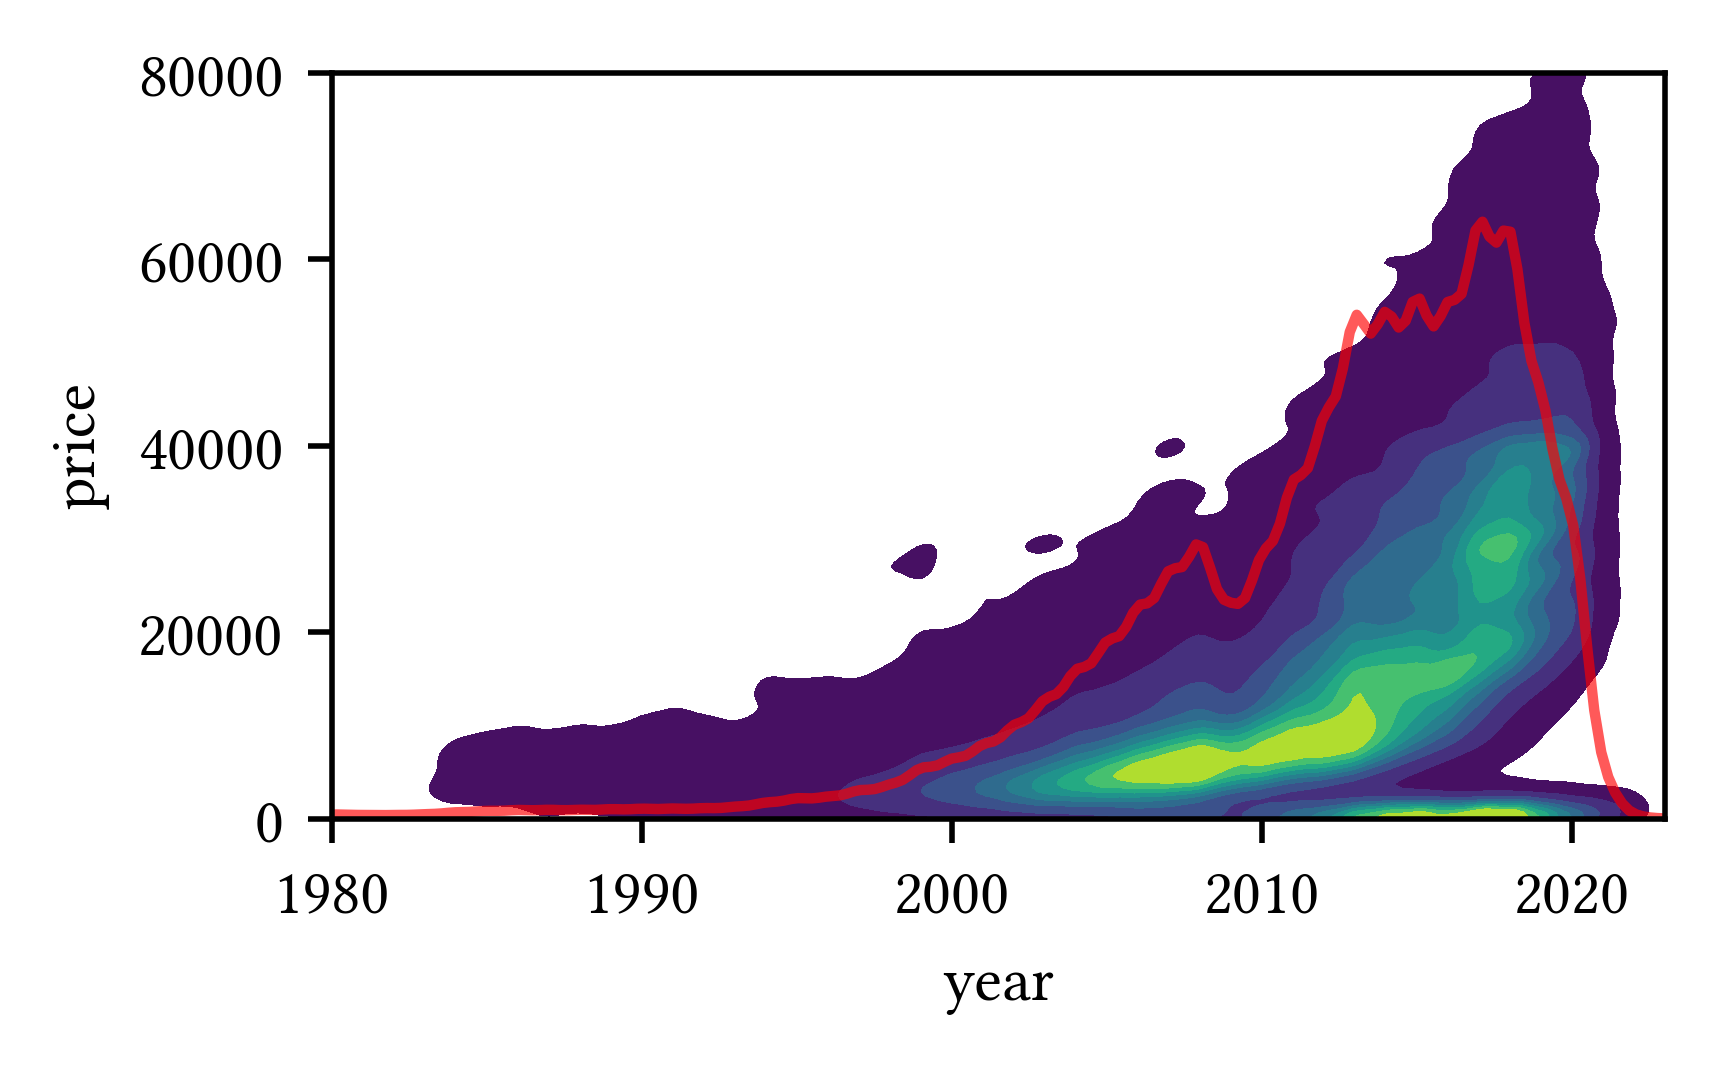

In [137]:
fig, ax = plt.subplots(figsize=(3.5, 2.2))

filtered = df[(df["price"] < 80000) & (df["year"] >= 1980)]

sns.kdeplot(
    data=filtered,
    x="year",
    y="price",
    ax=ax,
    fill=True,
    cmap="viridis",
    levels=10,
    thresh=0.02,
    bw_adjust=0.75,
)

kde = sns.kdeplot(
    data=filtered,
    x="year",
    bw_adjust=1.0,
    ax=ax,
    color="red",
    linewidth=1.5,
    alpha=0.65,
)

line = kde.lines[-1]
x, y = line.get_data()

y_scaled = (y / y.max()) * 80000
y_scaled *= 0.8

line.set_data(x, y_scaled)

ax.set_xlim(1980, 2023)
ax.set_ylim(0, 80000)

fig.tight_layout()
plt.savefig(images_path / "year_price_heatmap.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Preprocess

In [138]:
df = df_og.copy()[[col_label] + cols_features_num + cols_features_cat]

### Remove Boundaries

Remove all entries where price is lower than 500 or higher than 80000

In [139]:
df = df[(df["price"] >= 500) & (df["price"] <= 80000)]
len(df)

383159

Remove all entries where year is lower than 1980

In [140]:
df = df[df["year"] >= 1980]
len(df)

374159

### Drop Missing

In [141]:
df = df[df["year"].notna() & df["odometer"].notna()]
len(df)

372142

### Require Complete

In [142]:
cols_complete = [col_label, "region", "state"]

for c in cols_complete:
    assert c in df.columns, f"Missing required column: {c}"
    assert df[c].notna().all(), f"Column '{c}' contains missing values"

### Mark Missing

In [143]:
def mark_missing(df, col):
    df[f"{col}_missing"] = df[col].isna().astype(int)


for col in ["manufacturer"]:
    mark_missing(df, col)

### Train Test Split

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    df[cols_features_num + cols_features_cat],
    df[col_label],
    test_size=0.25,
    random_state=RNG,
)

### Target Encode

In [145]:
cols_cat_target = ["region", "state", "manufacturer"]

target_encoder = TargetEncoder(target_type="continuous", random_state=RNG).fit(
    X_train[cols_cat_target], y_train
)
X_train[cols_cat_target], X_test[cols_cat_target] = (
    target_encoder.transform(X_train[cols_cat_target]),
    target_encoder.transform(X_test[cols_cat_target]),
)

### One Hot Encode

In [146]:
cols_cat_one_hot = [
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
]

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(
    X_train[cols_cat_one_hot]
)
X_train = pd.concat(
    [
        X_train.drop(columns=cols_cat_one_hot),
        pd.DataFrame(
            one_hot_encoder.transform(X_train[cols_cat_one_hot]),
            columns=one_hot_encoder.get_feature_names_out(cols_cat_one_hot),
            index=X_train.index,
        ),
    ],
    axis=1,
)
X_test = pd.concat(
    [
        X_test.drop(columns=cols_cat_one_hot),
        pd.DataFrame(
            one_hot_encoder.transform(X_test[cols_cat_one_hot]),
            columns=one_hot_encoder.get_feature_names_out(cols_cat_one_hot),
            index=X_test.index,
        ),
    ],
    axis=1,
)

### Scaling

In [147]:
scaler = StandardScaler().fit(X_train)
scaler.set_output(transform="pandas")
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Result

In [148]:
X_train

,year,odometer,region,state,manufacturer,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,...,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,paint_color_nan
192405,0.627725,-0.199020,-0.830981,-1.080553,-1.209380,-0.561215,-0.125738,-0.672190,4.309759,-0.049927,...,-0.127215,-0.132297,3.993285,-0.065187,-0.039781,-0.280847,-0.341111,-0.483600,-0.067422,-0.635129
149647,0.004173,0.540413,0.097051,-0.486124,-0.330281,-0.561215,-0.125738,-0.672190,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,-0.280847,-0.341111,-0.483600,-0.067422,1.574483
350319,-0.151715,0.119943,-0.160044,-0.049043,0.458224,1.781848,-0.125738,-0.672190,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,-0.280847,-0.341111,2.067826,-0.067422,-0.635129
242775,-0.151715,0.102479,-0.556644,0.325428,-1.283178,1.781848,-0.125738,-0.672190,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,3.560662,-0.341111,-0.483600,-0.067422,-0.635129
211748,-1.866483,1.088908,-1.560064,-0.883373,-0.330281,-0.561215,-0.125738,-0.672190,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,-0.280847,-0.341111,-0.483600,-0.067422,1.574483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273180,1.095389,-0.598259,-1.023035,-0.260491,1.269857,-0.561215,-0.125738,-0.672190,-0.232032,20.029229,...,-0.127215,-0.132297,3.993285,-0.065187,-0.039781,-0.280847,-0.341111,-0.483600,-0.067422,-0.635129
191617,0.004173,-0.658899,-0.726895,-1.080553,-1.131823,-0.561215,-0.125738,1.487674,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,-0.280847,-0.341111,-0.483600,-0.067422,-0.635129
202639,0.160061,-0.166679,-0.141619,-1.310744,0.505728,-0.561215,-0.125738,1.487674,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,-0.280847,-0.341111,-0.483600,-0.067422,1.574483
27252,0.627725,-0.455760,0.100609,-0.182342,0.197331,-0.561215,-0.125738,-0.672190,-0.232032,-0.049927,...,-0.127215,-0.132297,-0.250420,-0.065187,-0.039781,3.560662,-0.341111,-0.483600,-0.067422,-0.635129


In [149]:
X_train.shape, X_test.shape

((279106, 69), (93036, 69))

### Save

In [150]:
pd.concat([X_train, y_train], axis=1).to_csv(
    temp_dir / "vehicles_train.csv", index=False
)
pd.concat([X_test, y_test], axis=1).to_csv(temp_dir / "vehicles_test.csv", index=False)